# 05 · Supervised Learning with scikit-learn — Part I

From here on we use **scikit-learn**, whose whole API is three verbs: `fit`, `predict`,
`score`. Learn them once and every model in the library works the same way.

This notebook covers the first family of classifiers and the ideas that surround them:

- The universal **`fit` / `predict` / `score`** workflow and the **train/test split**.
- **k-Nearest Neighbors** — the simplest possible model.
- **Logistic regression & linear SVM** — fast, strong linear baselines.
- **Decision trees** — rules a human can read.
- **Model complexity** and how it shows up as under/overfitting.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target
# stratify keeps the class ratio identical in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"train: {X_train.shape}  test: {X_test.shape}  features: {len(data.feature_names)}")

train: (426, 30)  test: (143, 30)  features: 30


## 1. The one workflow to rule them all

Every estimator: create it, `.fit(X_train, y_train)` to learn, `.predict(X_test)` for labels,
`.score(X_test, y_test)` for accuracy. Here it is with k-Nearest Neighbors, which classifies
a point by majority vote of its closest neighbors.

In [2]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("first 10 predictions:", knn.predict(X_test[:10]))
print(f"test accuracy: {knn.score(X_test, y_test):.1%}")

first 10 predictions: [1 0 1 1 1 0 0 0 0 1]
test accuracy: 93.0%


### Model complexity, seen directly

`n_neighbors` controls kNN's complexity. **Few** neighbors = jagged, overfit boundary;
**many** neighbors = smooth, possibly underfit. Plotting train vs test accuracy across the
setting reveals the sweet spot — a pattern you'll use for tuning *any* model.

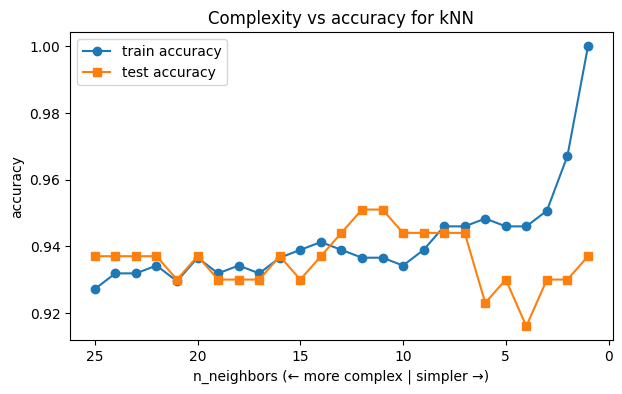

best k on test: 11


In [3]:
ks = range(1, 26)
train_acc, test_acc = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))

plt.figure(figsize=(7, 4))
plt.plot(ks, train_acc, "o-", label="train accuracy")
plt.plot(ks, test_acc, "s-", label="test accuracy")
plt.xlabel("n_neighbors (← more complex | simpler →)")
plt.ylabel("accuracy"); plt.title("Complexity vs accuracy for kNN")
plt.legend(); plt.gca().invert_xaxis(); plt.show()
print("best k on test:", ks[int(np.argmax(test_acc))])

## 2. Linear models: logistic regression & linear SVM

For high-dimensional data (like these 30 features) fast linear models are usually the right
first thing to try. Both draw a linear boundary; both expose a regularization strength `C`
(smaller `C` = stronger regularization = simpler model). We scale features first because
distance/magnitude-based models need it.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)

for name, model in [("LogisticRegression", LogisticRegression(max_iter=5000)),
                    ("LinearSVC",          LinearSVC(max_iter=5000))]:
    model.fit(Xtr_s, y_train)
    print(f"{name:20} test accuracy: {model.score(Xte_s, y_test):.1%}")

LogisticRegression   test accuracy: 98.6%
LinearSVC            test accuracy: 97.2%


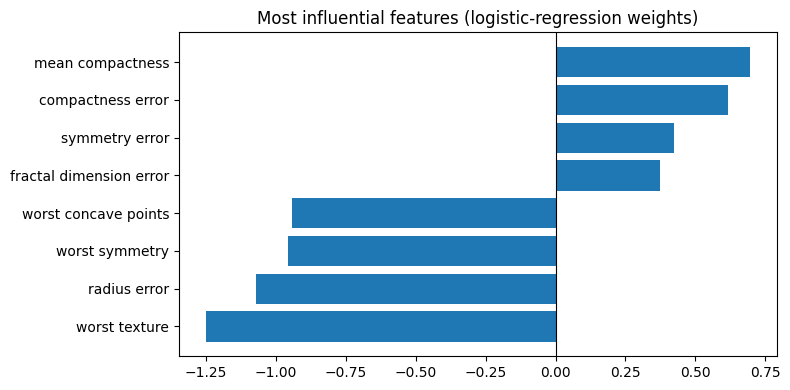

In [5]:
# Logistic-regression coefficients are interpretable: which features push toward each class?
lr = LogisticRegression(max_iter=5000).fit(Xtr_s, y_train)
coefs = lr.coef_[0]
order = np.argsort(coefs)
top = np.r_[order[:4], order[-4:]]     # 4 most negative + 4 most positive

plt.figure(figsize=(8, 4))
plt.barh(range(len(top)), coefs[top])
plt.yticks(range(len(top)), [data.feature_names[i] for i in top])
plt.title("Most influential features (logistic-regression weights)")
plt.axvline(0, color="k", lw=0.8); plt.tight_layout(); plt.show()

## 3. Decision trees: models you can read

A decision tree asks a sequence of yes/no questions about features. It needs no scaling,
handles non-linear patterns, and — crucially — you can *look at it*. Its depth controls
complexity: deep trees overfit hard.

tree test accuracy: 94.4%


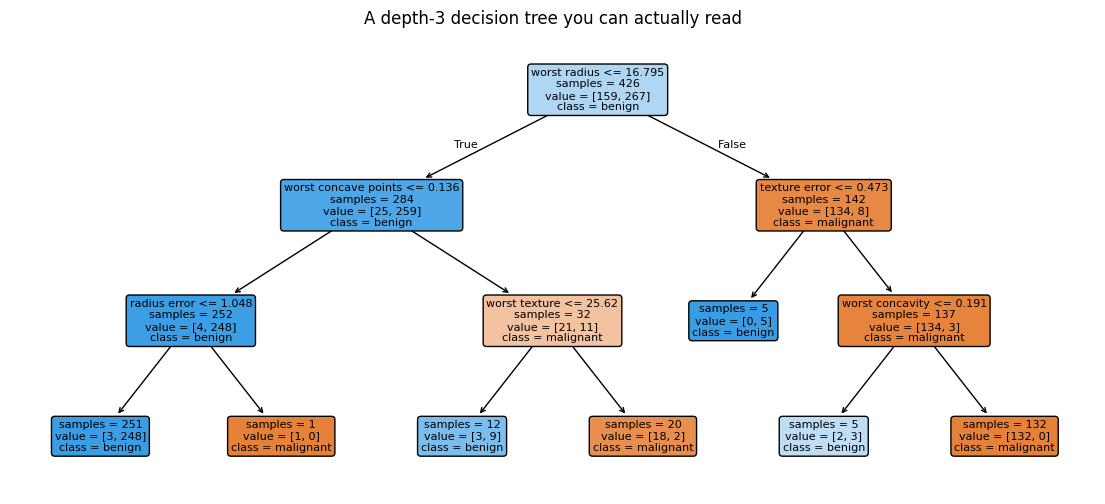

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
print(f"tree test accuracy: {tree.score(X_test, y_test):.1%}")

plt.figure(figsize=(14, 6))
plot_tree(tree, feature_names=data.feature_names, class_names=list(data.target_names),
          filled=True, rounded=True, fontsize=8, impurity=False)
plt.title("A depth-3 decision tree you can actually read"); plt.show()

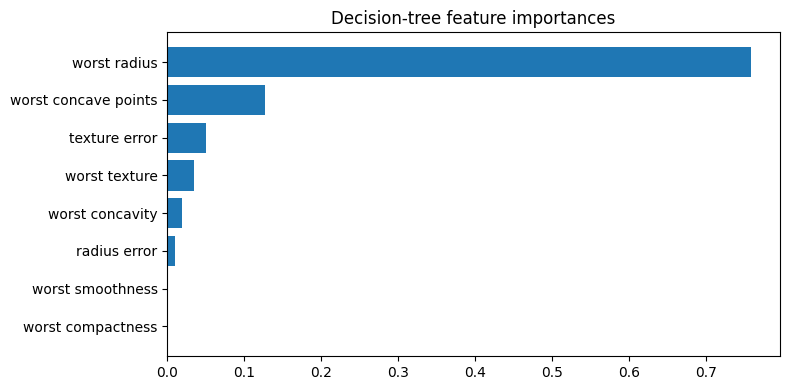

In [7]:
# Feature importances: how much each feature reduced impurity across the tree
imp = tree.feature_importances_
idx = np.argsort(imp)[-8:]
plt.figure(figsize=(8, 4))
plt.barh(range(len(idx)), imp[idx])
plt.yticks(range(len(idx)), [data.feature_names[i] for i in idx])
plt.title("Decision-tree feature importances"); plt.tight_layout(); plt.show()

## Recap

- The **`fit`/`predict`/`score`** API is identical for every model.
- Always **split** (and usually **stratify**) before evaluating.
- **kNN** is dead simple; **complexity curves** find the sweet spot.
- **Linear models** (LogReg, LinearSVC) are strong, fast, interpretable baselines — scale first.
- **Decision trees** are readable and scale-free but overfit when deep.

**Next:** `06 — Supervised Learning II`: ensembles, kernel SVMs, neural nets, and probabilities.